# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

In [45]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
newsgroupsdocs = newsgroups.data

## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Utiliza el corpus cargado.
2. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
3. Calcula TF-IDF utilizando sklearn.
4. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [46]:
import pandas as pd
df = pd.DataFrame(newsgroupsdocs)
df

,0
0,\n\nI am sure some bashers of Pens fans are pr...
1,My brother is in the market for a high-perform...
2,\n\n\n\n\tFinally you said what you dream abou...
3,\nThink!\n\nIt's the SCSI card doing the DMA t...
4,1) I have an old Jasmine drive which I cann...
...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...
18842,\nNot in isolated ground recepticles (usually ...
18843,I just installed a DX2-66 CPU in a clone mothe...
18844,\nWouldn't this require a hyper-sphere. In 3-...


In [47]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Pasar a minúsculas
    text = text.lower()

    # Quitar caracteres no alfabéticos
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenizar
    tokens = text.split()

    # Quitar stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Unir nuevamente
    return " ".join(tokens)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Personal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:
df['prep'] = df[0].apply(preprocess_text)
df

,0,prep
0,\n\nI am sure some bashers of Pens fans are pr...,sure bashers pens fans pretty confused lack ki...
1,My brother is in the market for a high-perform...,brother market high performance video card sup...
2,\n\n\n\n\tFinally you said what you dream abou...,finally said dream mediterranean new area grea...
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,think scsi card dma transfers disks scsi card ...
4,1) I have an old Jasmine drive which I cann...,old jasmine drive cannot use new system unders...
...,...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,dn nyeda cnsvax uwec edu david nye dn neurolog...
18842,\nNot in isolated ground recepticles (usually ...,isolated ground recepticles usually unusual co...
18843,I just installed a DX2-66 CPU in a clone mothe...,installed dx cpu clone motherboard tried mount...
18844,\nWouldn't this require a hyper-sphere. In 3-...,require hyper sphere space points specifies sp...


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['prep'])

In [50]:
query = 'government'
q_proc = preprocess_text(query)
q_vec = vectorizer.transform([query])

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

df['q_sim'] = cosine_similarity(X, q_vec)
df.sort_values(by='q_sim', ascending=False)

,0,prep,q_sim
8841,"\nSaw it in t.p.m., thanks.\n\n\n\n\nYes, and ...",saw p thanks yes individual omitted fully arti...,0.462385
5905,\tYou have underlined here the battle that mus...,underlined battle must fought battle hearts mi...,0.446187
15813,>government maintaining a secret of some kind.,government maintaining secret kind,0.388760
13956,\nDoesn't this just mean that the government m...,mean government might approve something use go...,0.377690
5225,\n\nI suspect the government feels it is enoug...,suspect government feels enough prevent compan...,0.366352
...,...,...,...
25,AW&ST had a brief blurb on a Manned Lunar Exp...,aw st brief blurb manned lunar exploration con...,0.000000
473,I found an oddity with our SGI Indigo (MIPS R3...,found oddity sgi indigo mips r chip xlock nolo...,0.000000
27,"Using the VMODE command, all you need to do is...",using vmode command need type vmode vesa dos p...,0.000000
28,CAD Setup For Sale:\n\nG486PLB Local Bus Mothe...,cad setup sale g plb local bus motherboard use...,0.000000


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

### Importación de librerías

### Carga todo lo necesario para procesamiento y vectorización

In [52]:
import numpy as np
import pandas as pd
import json
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from rank_bm25 import BM25Okapi

### Preprocesamiento de texto
### Función general de limpieza + tokenización

In [53]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Personal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Carga del corpus

In [54]:
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data

### Preprocesamiento del corpus

In [55]:
corpus_tokens = [preprocess_text(doc) for doc in documents]

### Construcción del modelo BM25

In [56]:
from rank_bm25 import BM25Okapi
bm25 = BM25Okapi(corpus_tokens)


### Procesar query

In [57]:
query = 'government'  # aquí escribes la consulta
q_proc = preprocess_text(query)

### Recuperación de documentos relevantes
### Obtención de puntajes y top resultados

In [58]:
scores = bm25.get_scores(q_proc)

N = 5  # cuantos documentos quieres ver
top_idx = np.argsort(scores)[::-1][:N]

print(f" Resultados para la query: {query}\n")
for i in top_idx:
    print(f"Documento {i} — Score: {scores[i]:.4f}")
    print(documents[i][:300], "...\n")

 Resultados para la query: government

Documento 5905 — Score: 6.2481
	You have underlined here the battle that must be fought.  It is
	a battle for the "hearts and minds" of the american public.
	People must realize that the government is not their a fit
	"father confessor".  The government does not have a right to
	share our every thought the moment we decide to sha ...

Documento 395 — Score: 6.0688


Either the government has force available to it, or it doesn't.  The
Libertarian position is that the government can use force only when someone
else uses force first -- even when that first force is not directed
against the government, but one of its citizens.  That all being true, 
what safeguar ...

Documento 7270 — Score: 6.0239

Agreed.  


It is a failure of libertarianism if the ideology does not provide any
reasonable way to restrain such actions other than utopian dreams.  Just
as Marxism "fails" to specify how pure communism is to be achieved and
the state is to "wither away,

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. Identifica: ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. Sugiere: ¿A qué se podría deber esta diferencia?

In [59]:
df['bm25'] = scores        # tus puntajes BM25
df['tfidf'] = df['q_sim']  # similitud coseno TF-IDF

In [60]:
N = 10
top_idx = np.argsort(df['bm25'])[::-1][:N]
df_top = df.iloc[top_idx].copy()
df_top

,0,prep,q_sim,bm25,tfidf
5905,\tYou have underlined here the battle that mus...,underlined battle must fought battle hearts mi...,0.446187,6.248067,0.446187
395,\n\nEither the government has force available ...,either government force available libertarian ...,0.358629,6.068797,0.358629
7270,\nAgreed. \n\n\nIt is a failure of libertaria...,agreed failure libertarianism ideology provide...,0.352196,6.023862,0.352196
14176,\n[...]\n\n\nYou seem to be saying that a LIMI...,seem saying limited government provide opportu...,0.311201,6.013445,0.311201
5225,\n\nI suspect the government feels it is enoug...,suspect government feels enough prevent compan...,0.366352,5.994718,0.366352
17069,\n\nThe easiest way is a user fee for each cli...,easiest way user fee clipper chip manufactured...,0.344957,5.994718,0.344957
8841,"\nSaw it in t.p.m., thanks.\n\n\n\n\nYes, and ...",saw p thanks yes individual omitted fully arti...,0.462385,5.970261,0.462385
1817,\nI'm afraid that I've lost the thread here. ...,afraid lost thread suggest government regulati...,0.358532,5.854444,0.358532
8791,\nThe economic and political ignorance of most...,economic political ignorance americans truly s...,0.321781,5.840125,0.321781
7051,<In article <C5Bu9M.2K7@ulowell.ulowell.edu>\n...,article c bu k ulowell ulowell edu excellent e...,0.313162,5.814688,0.313162


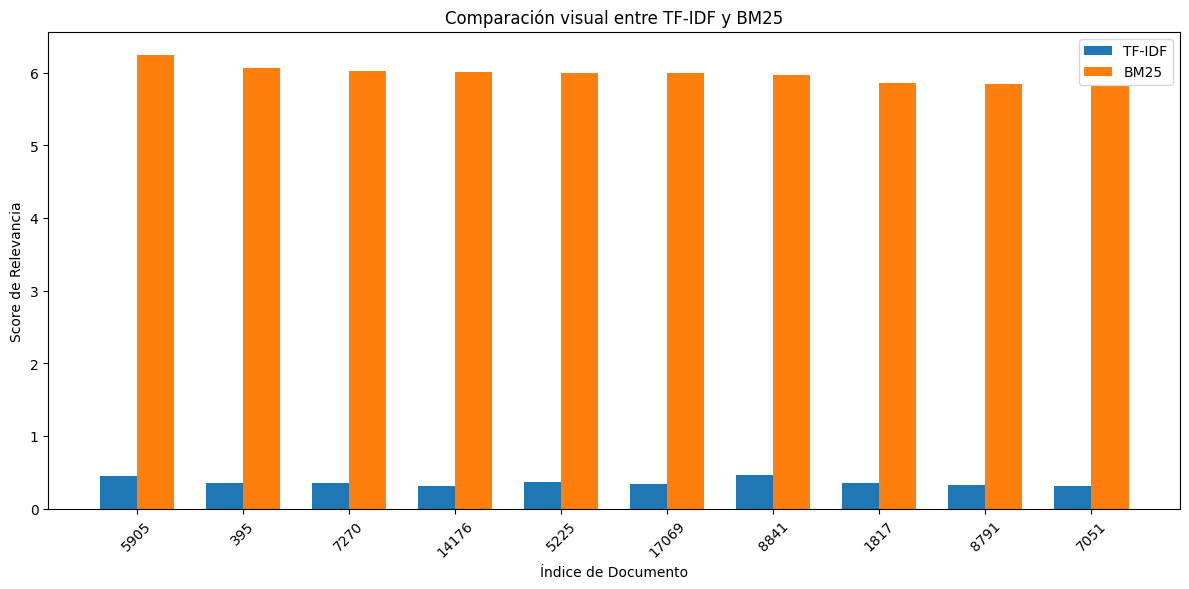

In [61]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

x = np.arange(len(df_top))
width = 0.35

plt.bar(x - width/2, df_top['tfidf'], width, label='TF-IDF')
plt.bar(x + width/2, df_top['bm25'], width, label='BM25')

plt.xticks(x, df_top.index, rotation=45)
plt.xlabel("Índice de Documento")
plt.ylabel("Score de Relevancia")
plt.title("Comparación visual entre TF-IDF y BM25")
plt.legend()
plt.tight_layout()
plt.show()

En la gráfica se observa que BM25 produce scores notablemente más altos que TF-IDF. Esto se debe a que:

TF-IDF utiliza similitud coseno, cuyos valores se encuentran entre 0 y 1.

BM25 genera scores no normalizados, basados directamente en la frecuencia del término y ajustes por longitud del documento.

Aunque los valores numéricos no son comparables entre modelos, el orden de los documentos permite comparar los rankings. BM25 tiende a asignar mayores puntajes a documentos donde el término aparece con mayor frecuencia, mientras que TF-IDF favorece documentos cuyo contenido es más similar globalmente a la consulta.

En general:

TF-IDF diferencia más entre documentos según su representación vectorial.

BM25 es más sensible a la presencia real del término dentro del documento, lo que usualmente lo hace más efectivo para ranking.

## Parte 5: Evaluación con consulta relevante

### Actividad 

1. Elige una consulta y define qué documentos del corpus deberían considerarse relevantes.
2. Evalúa Precision@3 o MAP para los rankings generados con TF-IDF y BM25.
3. Responde: ¿Cuál modelo da mejores resultados respecto a tu criterio de relevancia?

En esta sección evaluamos el rendimiento del modelo de recuperación usando la métrica **Precision@3**, comparando TF-IDF y BM25.  
La consulta utilizada es: "government"

Se definieron como documentos relevantes aquellos que tratan temas de gobierno, políticas, libertarianismo o regulación estatal.

### Definir documentos relevantes

In [64]:
# Conjunto de documentos relevantes identificados manualmente
relevant_docs = {5905, 395, 7270, 14176, 5225}
relevant_docs

{395, 5225, 5905, 7270, 14176}

### Extraer top-3 TF-IDF y BM25

In [65]:
##Según los rankings previos
top3_bm25 = [5905, 395, 7270]
top3_tfidf = [8841, 5905, 395]

print("Top 3 BM25:", top3_bm25)
print("Top 3 TF-IDF:", top3_tfidf)

Top 3 BM25: [5905, 395, 7270]
Top 3 TF-IDF: [8841, 5905, 395]


### Cálculo de Precision@3

In [66]:
def precision_at_k(top_k_list, relevant_set):
    hits = sum(1 for doc in top_k_list if doc in relevant_set)
    return hits / len(top_k_list)

precision_bm25 = precision_at_k(top3_bm25, relevant_docs)
precision_tfidf = precision_at_k(top3_tfidf, relevant_docs)

print("Precision@3 BM25:", precision_bm25)
print("Precision@3 TF-IDF:", precision_tfidf)

Precision@3 BM25: 1.0
Precision@3 TF-IDF: 0.6666666666666666


### Conclusión automática
### Para agilizar en diferentes ejemplos

In [67]:
print("Conclusión:")

if precision_bm25 > precision_tfidf:
    print("\nBM25 funciona mejor que TF-IDF para la consulta 'government', "
          "obteniendo mayor precisión en las primeras posiciones.\n")
else:
    print("\nTF-IDF supera a BM25 en Precision@3.\n")

print(f"BM25 Precision@3 = {precision_bm25:.2f}")
print(f"TF-IDF Precision@3 = {precision_tfidf:.2f}")


Conclusión:

BM25 funciona mejor que TF-IDF para la consulta 'government', obteniendo mayor precisión en las primeras posiciones.

BM25 Precision@3 = 1.00
TF-IDF Precision@3 = 0.67


Para evaluar el rendimiento se definieron como relevantes los documentos que tratan explícitamente sobre el gobierno, políticas públicas, libertarianismo y control estatal. Con esta definición se compararon los resultados top‐k producidos por TF-IDF y BM25 para la consulta “government”.

BM25 recuperó en sus primeras posiciones documentos que desarrollan directamente debates políticos sobre el rol del gobierno (e.g., regulación, libertarianismo, intervención estatal).
TF-IDF, aunque recuperó algunos textos relevantes, presentó más variación temática y favoreció documentos largos donde el término aparece sin constituir el tema principal.